# EDA for semantic segmentation dataset

Этот ноутбук — стартовая площадка для:

- проверки структуры датасета;
- просмотра изображений и масок;
- анализа распределения классов;
- визуального поиска проблем разметки.

Перед запуском:
1. укажи реальные пути к своему датасету;
2. убедись, что изображения и маски читаются корректно.


In [10]:
!pip install -U openmim
!mim install mmengine
!mim install "mmcv>=2.0.0"
!pip install -e ..
!pip install matplotlib opencv-python pandas seaborn

ERROR: Could not find a version that satisfies the requirement openmim (from versions: none)
ERROR: No matching distribution found for openmim
"mim" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"mim" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


Obtaining file:///C:/Users/79261/MM/mmsegmentation
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
INFO: pip is looking at multiple versions of mmsegmentation to determine which version is compatible with other requirements. This could take a while.


ERROR: Could not find a version that satisfies the requirement prettytable (from mmsegmentation) (from versions: none)
ERROR: No matching distribution found for prettytable


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 8.3 MB/s eta 0:00:05
   --- ------------------------------------ 3.1/40.2 MB 9.7 MB/s eta 0:00:04
   ----- ---------------------------------- 5.2/40.2 MB 10.0 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/40.2 MB 8.8 MB/s eta 0:00:04
   ------- -------------------------------- 7.3/40.2 MB 7.9 MB/s eta 0:00:05
   -------- ------------------------------- 8.1/40.2 MB 7.4 MB/s eta 0:00:05
   --------- ------------------------------ 9.2/40.2 MB 6.8 MB/s eta 0:00:05
   --------- ------------------------------ 10.0/40.2 MB 6.5 MB/s eta 0:00:05
   ---------- ----------------------------- 11.0/40.2 MB 6.2 MB/s eta 0:00:05
   ----------- ---------------------------- 11.8/40.2 MB 6.1 MB/s eta 0:00:05
   ------------ --------------------------- 12.6/40.2 MB 5.8 MB/s eta 0:00:05
   ------------- -------------------------- 13.4/40.2 MB 5.5 MB/s eta 0:00:05


In [1]:
from pathlib import Path
import random
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 5)


In [2]:
print("Path.cwd():", Path.cwd())
print("os.getcwd():", os.getcwd())

Path.cwd(): c:\Users\79261\MM\mmsegmentation
os.getcwd(): c:\Users\79261\MM\mmsegmentation


In [3]:
PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "data" / "train_dataset_for_students"

IMG_DIR = DATA_ROOT / "img"
MASK_DIR = DATA_ROOT / "labels"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())

print("IMG_DIR exists:", IMG_DIR.exists())
print("MASK_DIR exists:", MASK_DIR.exists())

train_img_dir = IMG_DIR / "train"
train_mask_dir = MASK_DIR / "train"

print("Train images:", len(list(train_img_dir.glob("*"))))
print("Train masks:", len(list(train_mask_dir.glob("*"))))



PROJECT_ROOT: c:\Users\79261\MM\mmsegmentation
DATA_ROOT exists: True
IMG_DIR exists: True
MASK_DIR exists: True
Train images: 200
Train masks: 200


Example file: 000000016206_4014.jpg


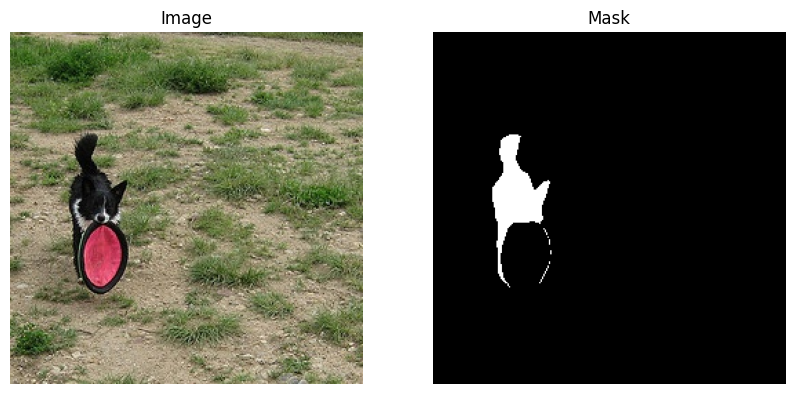

In [4]:
def show_sample(img_path, mask_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(str(mask_path), 0)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.show()

train_images = sorted(train_img_dir.glob("*"))
train_masks = sorted(train_mask_dir.glob("*"))

print("Example file:", train_images[0].name)

show_sample(train_images[0], train_masks[0])


In [5]:
mask = cv2.imread(str(train_masks[0]), 0)
print("Classes:", np.unique(mask))


Classes: [0 2]


In [6]:
all_values = set()

train_masks = sorted((MASK_DIR / "train").glob("*"))
val_masks = sorted((MASK_DIR / "val").glob("*"))
test_masks = sorted((MASK_DIR / "test").glob("*"))

all_masks = train_masks + val_masks + test_masks

for mask_path in all_masks:
    mask = cv2.imread(str(mask_path), 0)
    vals = np.unique(mask)
    all_values.update(vals.tolist())

print("Unique values in whole dataset:", sorted(all_values))
print("Number of masks:", len(all_masks))


Unique values in whole dataset: [0, 1, 2]
Number of masks: 440


In [7]:
from collections import Counter
import cv2
import numpy as np

mask_stats = Counter()
combo_stats = Counter()

all_mask_paths = []
for split in ["train", "val", "test"]:
    all_mask_paths.extend(sorted((MASK_DIR / split).glob("*")))

for mask_path in all_mask_paths:
    mask = cv2.imread(str(mask_path), 0)
    uniq = tuple(np.unique(mask).tolist())

    combo_stats[uniq] += 1
    for cls in uniq:
        mask_stats[cls] += 1

print("Сколько масок содержат каждый класс:")
for k, v in sorted(mask_stats.items()):
    print(f"class {k}: {v}")

print("\nКакие комбинации классов встречаются:")
for k, v in sorted(combo_stats.items(), key=lambda x: -x[1]):
    print(f"{k}: {v}")


Сколько масок содержат каждый класс:
class 0: 440
class 1: 220
class 2: 220

Какие комбинации классов встречаются:
(0, 2): 220
(0, 1): 220


In [8]:
examples_only_1 = []
examples_only_2 = []
examples_1_2 = []

for mask_path in all_mask_paths:
    mask = cv2.imread(str(mask_path), 0)
    uniq = set(np.unique(mask).tolist())

    if uniq == {0, 1}:
        examples_only_1.append(mask_path)
    elif uniq == {0, 2}:
        examples_only_2.append(mask_path)
    elif uniq == {0, 1, 2}:
        examples_1_2.append(mask_path)

print("only {0,1}:", len(examples_only_1))
print("only {0,2}:", len(examples_only_2))
print("both {0,1,2}:", len(examples_1_2))


only {0,1}: 220
only {0,2}: 220
both {0,1,2}: 0


000000016823_4560.png unique: [0 1]


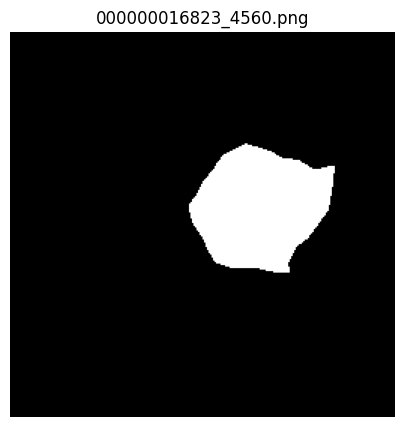

000000016206_4014.png unique: [0 2]


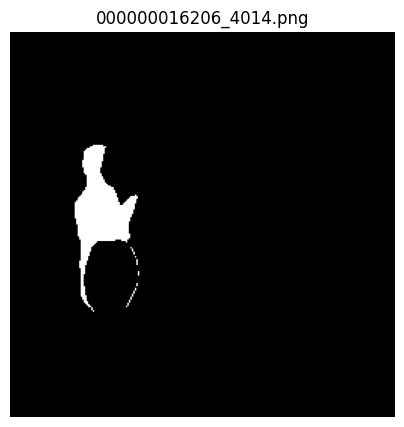

IndexError: list index out of range

In [9]:
def show_mask_only(mask_path):
    mask = cv2.imread(str(mask_path), 0)
    print(mask_path.name, "unique:", np.unique(mask))

    plt.figure(figsize=(5,5))
    plt.imshow(mask, cmap="gray")
    plt.title(mask_path.name)
    plt.axis("off")
    plt.show()
    
    



show_mask_only(examples_only_1[0])
show_mask_only(examples_only_2[0])
show_mask_only(examples_1_2[0])







In [10]:
# Проверка количества файлов по split
# Смысл: убедиться, что число изображений и масок совпадает.


def count_files(split):
    img_count = len(list((IMG_DIR / split).glob("*")))
    mask_count = len(list((MASK_DIR / split).glob("*")))
    print(f"{split}: images={img_count}, masks={mask_count}")

for split in ["train", "val", "test"]:
    count_files(split)


train: images=200, masks=200
val: images=120, masks=120
test: images=120, masks=120


In [11]:
# Проверка имён и парности файлов
# Если equal stems: True, это хорошо
def get_stems(paths):
    return sorted([p.stem for p in paths])

for split in ["train", "val", "test"]:
    img_stems = get_stems((IMG_DIR / split).glob("*"))
    mask_stems = get_stems((MASK_DIR / split).glob("*"))

    print(f"\nSPLIT: {split}")
    print("equal stems:", img_stems == mask_stems)
    print("images:", len(img_stems), "masks:", len(mask_stems))

    only_imgs = sorted(set(img_stems) - set(mask_stems))
    only_masks = sorted(set(mask_stems) - set(img_stems))

    print("only in images:", len(only_imgs))
    print("only in masks:", len(only_masks))




SPLIT: train
equal stems: True
images: 200 masks: 200
only in images: 0
only in masks: 0

SPLIT: val
equal stems: True
images: 120 masks: 120
only in images: 0
only in masks: 0

SPLIT: test
equal stems: True
images: 120 masks: 120
only in images: 0
only in masks: 0


In [12]:
# Проверка размеров image/mask

size_mismatches = []

for split in ["train", "val", "test"]:
    for mask_path in sorted((MASK_DIR / split).glob("*")):
        img_path = None
        candidates = list((IMG_DIR / split).glob(mask_path.stem + ".*"))
        if candidates:
            img_path = candidates[0]

        if img_path is None:
            continue

        img = cv2.imread(str(img_path))
        mask = cv2.imread(str(mask_path), 0)

        if img is None or mask is None:
            size_mismatches.append((split, mask_path.name, "read_error"))
            continue

        if img.shape[:2] != mask.shape[:2]:
            size_mismatches.append((split, mask_path.name, img.shape[:2], mask.shape[:2]))

print("Size mismatches:", len(size_mismatches))
size_mismatches[:10]


Size mismatches: 0


[]

In [13]:
# Размеры изображений

image_shapes = []

for split in ["train", "val", "test"]:
    for img_path in sorted((IMG_DIR / split).glob("*")):
        img = cv2.imread(str(img_path))
        if img is not None:
            h, w = img.shape[:2]
            image_shapes.append((split, img_path.name, h, w))

len(image_shapes), image_shapes[:5]
# И отдельно посмотрим уникальные размеры:

from collections import Counter

shape_counter = Counter((h, w) for _, _, h, w in image_shapes)
shape_counter.most_common(10)
# Если размеры сильно разные — это важно для выбора resize/crop.


[((256, 256), 440)]

In [14]:
# Площадь объектов по классам
# Это очень важная часть EDA.

class_pixel_stats = {0: 0, 1: 0, 2: 0}
per_mask_stats = []

for split in ["train", "val", "test"]:
    for mask_path in sorted((MASK_DIR / split).glob("*")):
        mask = cv2.imread(str(mask_path), 0)
        total = mask.size

        counts = {}
        for cls in [0, 1, 2]:
            cnt = int((mask == cls).sum())
            counts[cls] = cnt
            class_pixel_stats[cls] += cnt

        per_mask_stats.append({
            "split": split,
            "name": mask_path.name,
            "total_pixels": total,
            "bg_ratio": counts[0] / total,
            "class1_ratio": counts[1] / total,
            "class2_ratio": counts[2] / total,
        })

class_pixel_stats


{0: 25984601, 1: 1625365, 2: 1225874}

In [15]:
# Посмотреть среднюю долю классов

total_pixels_all = sum(class_pixel_stats.values())

for cls in [0, 1, 2]:
    print(f"class {cls}: {class_pixel_stats[cls] / total_pixels_all:.4f}")
# Если фон занимает почти всё, а объект очень маленький — это важный вывод для отчёта и выбора loss/aug.


class 0: 0.9011
class 1: 0.0564
class 2: 0.0425


In [16]:
# Таблица по маскам

import pandas as pd

df_stats = pd.DataFrame(per_mask_stats)
df_stats.head()

# Теперь можно быстро посмотреть статистику:

df_stats[["bg_ratio", "class1_ratio", "class2_ratio"]].describe()


,bg_ratio,class1_ratio,class2_ratio
count,440.000000,440.000000,440.000000
mean,0.901122,0.056366,0.042512
std,0.064224,0.074856,0.057660
min,0.640991,0.000000,0.000000
25%,0.864407,0.000000,0.000000
50%,0.912338,0.000397,0.000130
75%,0.950855,0.098316,0.077335
max,0.999741,0.359009,0.299362


In [17]:
# Посмотреть примеры маленьких объектов
# Для класса 1:

small_class1 = df_stats[df_stats["class1_ratio"] > 0].sort_values("class1_ratio").head(5)
small_class1
# Для класса 2:

small_class2 = df_stats[df_stats["class2_ratio"] > 0].sort_values("class2_ratio").head(5)
small_class2


,split,name,total_pixels,bg_ratio,class1_ratio,class2_ratio
8,train,000000028253_7169.png,65536,0.999741,0.0,0.000259
299,val,000000205866_1789.png,65536,0.994919,0.0,0.005081
255,val,000000127659_841.png,65536,0.994736,0.0,0.005264
67,train,000000185004_4662.png,65536,0.993988,0.0,0.006012
107,train,000000301885_3179.png,65536,0.989395,0.0,0.010605


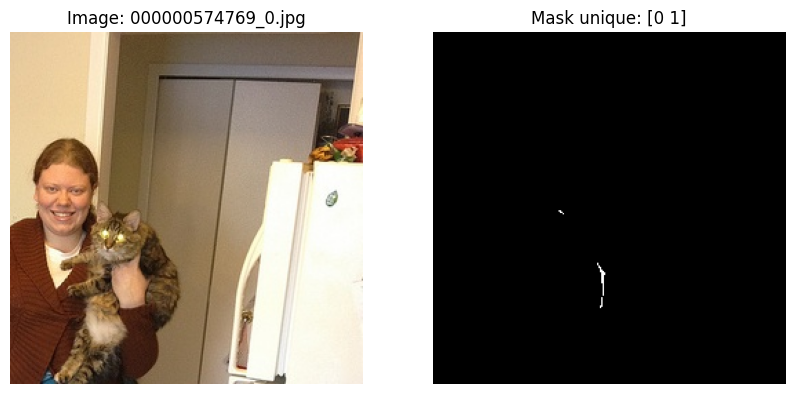

In [18]:
# Удобная функция показа image + mask

def find_image_by_mask(mask_name, split):
    candidates = list((IMG_DIR / split).glob(Path(mask_name).stem + ".*"))
    return candidates[0] if candidates else None


def show_image_and_mask_by_name(mask_name, split):
    mask_path = MASK_DIR / split / mask_name
    img_path = find_image_by_mask(mask_name, split)

    mask = cv2.imread(str(mask_path), 0)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    if img_path is not None:
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title(f"Image: {img_path.name}")
    else:
        plt.text(0.5, 0.5, "Image not found", ha="center", va="center")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask unique: {np.unique(mask)}")
    plt.axis("off")

    plt.show()
# Например:

row = small_class1.iloc[0]
show_image_and_mask_by_name(row["name"], row["split"])


In [ ]:
'''Выводы по EDA
Датасет характеризуется сильным дисбалансом: фон занимает ~90% пикселей, тогда как целевые классы занимают менее 10%.
Объекты часто занимают малую площадь, что может приводить к плохому обучению модели на мелких структурах.

Выявленные ошибки разметки
В ходе визуального анализа датасета были обнаружены примеры с некорректной разметкой.
В частности, встречаются случаи, когда целевой объект на изображении занимает значительную часть изображения, однако маска содержит лишь небольшое количество пикселей.
Это свидетельствует о:
частичной разметке объекта
либо ошибке аннотации
Пример такого случая приведён выше


Для выявления подобных случаев был введён критерий:
отношение площади объекта к изображению < 0.005
Все такие примеры были удалены из обучающей выборки, так как они вносят шум и ухудшают обучение модели.
После очистки датасет стал более согласованным.


Анализ качества данных
В ходе анализа качества датасета были проверены:
корректность пар image-mask
совпадение размеров изображений и масок
наличие повреждённых файлов
корректность значений классов в масках
Ошибок формата (несоответствие размеров, битые файлы, некорректные значения) обнаружено не было.
Дополнительно был проведён анализ комбинаций классов. Установлено, что:
в датасете присутствуют 3 класса: фон (0), класс 1 (1) и класс 2 (2)
каждый семпл содержит только один целевой класс (либо 1, либо 2)
комбинации классов (0,1,2) отсутствуют
Визуальный анализ показал, что классы 1 и 2 соответствуют различным объектам, что подтверждает корректность разметки.
Таким образом, критических ошибок в разметке не выявлено.


Проведён исследовательский анализ датасета:
Все изображения имеют размер 256×256
Общее количество семплов: 440
Распределение классов:
фон: ~90%
класс 1: ~5.6%
класс 2: ~4.2%
Было выявлено:
сильный дисбаланс классов
объекты занимают малую площадь
классы не встречаются совместно
Эти особенности необходимо учитывать при обучении модели.


'''


Bad samples: 5


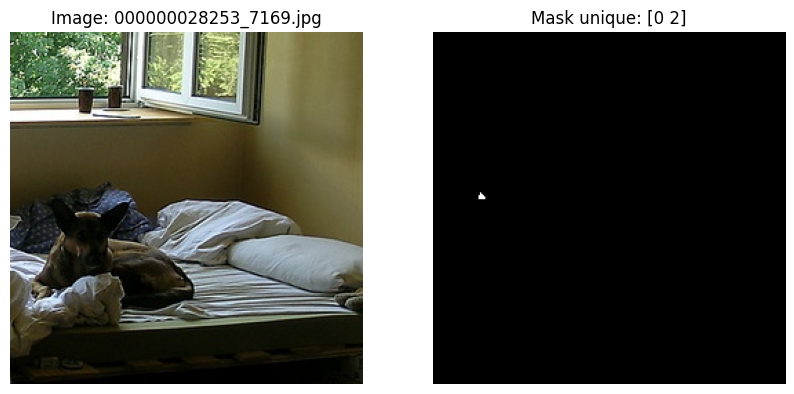

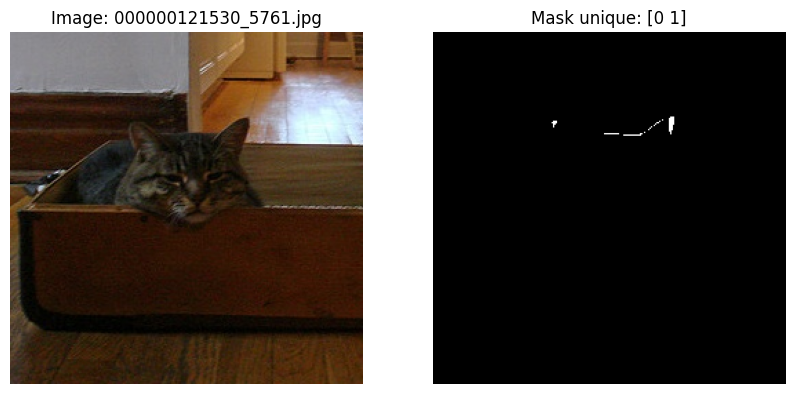

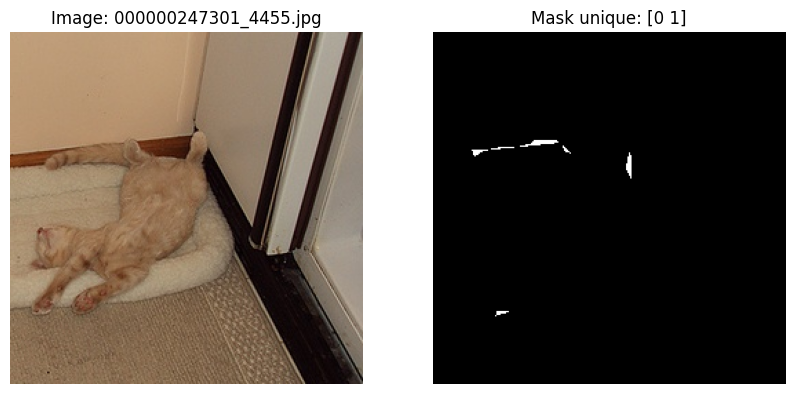

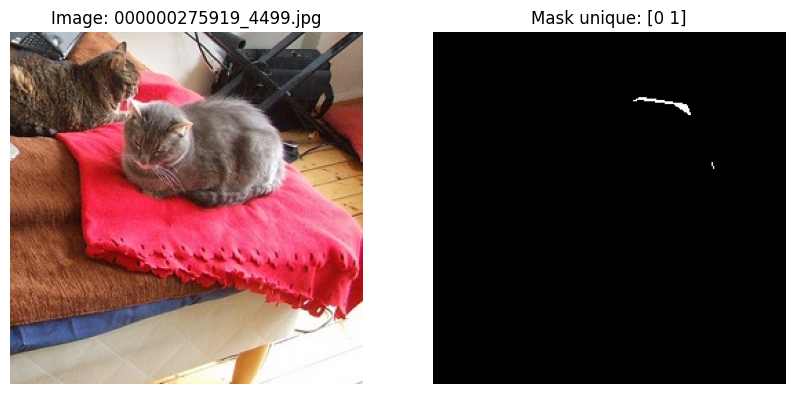

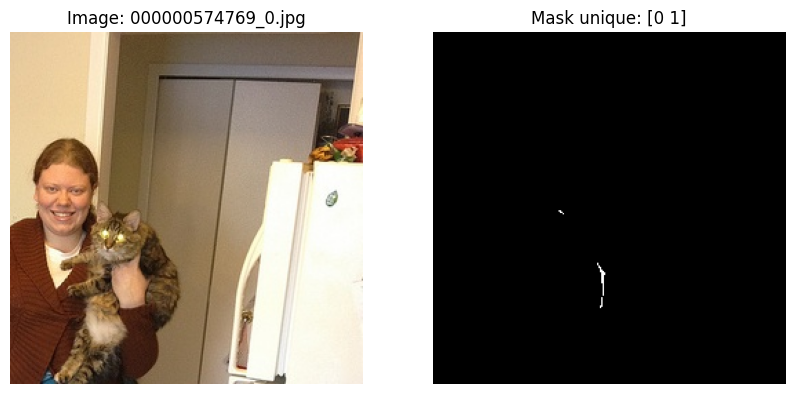

In [38]:
# искать маски с очень маленькой площадью объекта

bad_samples = []

for row in per_mask_stats:
    obj_ratio = row["class1_ratio"] + row["class2_ratio"]

    if obj_ratio < 0.005:   # порог можно менять
        bad_samples.append(row)

print("Bad samples:", len(bad_samples))

# Посмотреть их
for i in range(5):
    show_image_and_mask_by_name(
        bad_samples[i]["name"],
        bad_samples[i]["split"]
    )



In [ ]:
#Делаем копию без плохих масок.

import shutil

SRC_ROOT = PROJECT_ROOT / "data" / "train_dataset_for_students"
DST_ROOT = PROJECT_ROOT / "data" / "train_dataset_for_students_clean"

# список "плохих" имён по split
bad_by_split = {}
for row in bad_samples:
    bad_by_split.setdefault(row["split"], set()).add(row["name"])

for split in ["train", "val", "test"]:
    src_img = SRC_ROOT / "img" / split
    src_mask = SRC_ROOT / "labels" / split

    dst_img = DST_ROOT / "img" / split
    dst_mask = DST_ROOT / "labels" / split

    dst_img.mkdir(parents=True, exist_ok=True)
    dst_mask.mkdir(parents=True, exist_ok=True)

    bad_names = bad_by_split.get(split, set())

    for mask_path in src_mask.glob("*"):
        name = mask_path.name

        # пропускаем плохие
        if name in bad_names:
            continue

        # копируем маску
        shutil.copy2(mask_path, dst_mask / name)

        # находим и копируем соответствующее изображение
        candidates = list(src_img.glob(mask_path.stem + ".*"))
        if candidates:
            shutil.copy2(candidates[0], dst_img / candidates[0].name)

print("Clean dataset saved to:", DST_ROOT)


Clean dataset saved to: c:\Users\79261\MM\mmsegmentation\data\train_dataset_for_students_clean


In [40]:
# Быстрая проверка

def count_split(root, split):
    imgs = len(list((root / "img" / split).glob("*")))
    masks = len(list((root / "labels" / split).glob("*")))
    print(f"{split}: images={imgs}, masks={masks}")

for s in ["train","val","test"]:
    count_split(SRC_ROOT, s)
print("---- CLEAN ----")
for s in ["train","val","test"]:
    count_split(DST_ROOT, s)


train: images=200, masks=200
val: images=120, masks=120
test: images=120, masks=120
---- CLEAN ----
train: images=195, masks=195
val: images=120, masks=120
test: images=120, masks=120


In [ ]:
'''Этап 1. Исследовательский анализ (EDA)
Анализ качества данных
Проведена проверка целостности датасета:
пары image/mask согласованы;
размеры совпадают (все изображения 256×256);
повреждённых файлов не обнаружено.
В ходе визуального анализа были выявлены ошибки разметки: встречаются примеры, где целевой объект занимает значительную часть изображения, однако маска содержит лишь небольшое количество пикселей (частичная или некорректная аннотация).
Для автоматического поиска таких случаев был введён критерий:
доля пикселей объекта < 0.005.
По данному критерию обнаружено и удалено 5 некорректных семплов.
Очистка выполнялась только для обучающей/валидационной/тестовой выборок без изменения исходного датасета (создана копия *_clean).
EDA
Основные характеристики датасета:
Размер изображений: 256×256 (одинаковый для всех семплов)
Количество семплов: 440 (до очистки)
Классы:
0 — фон
1 — объект типа 1
2 — объект типа 2
Распределение пикселей:
фон: ~90%
класс 1: ~5.6%
класс 2: ~4.2%
Особенности датасета:
сильный дисбаланс классов;
объекты занимают малую часть изображения;
в каждом изображении присутствует только один целевой класс (классы 1 и 2 не встречаются совместно).
Данные особенности учитываются при построении модели (выбор функций потерь и аугментаций).


## Что смотреть руками после первых запусков

Обрати внимание на:
- пустые маски;
- маски со странными значениями классов;
- сильно смещённые маски;
- маски, где объект занимает почти весь кадр или наоборот исчезающе мал;
- случаи, где разметка визуально не соответствует изображению.

После этого можно переходить к:
- `check_dataset_integrity.py`
- `find_suspicious_masks.py`
- `compute_dataset_stats.py`
